## Learning Objectives

* Filter and sort data using Pandas
* Show how `.loc[]` works in Pandas
* Understand the Pandas `.groupby()` function for aggregations
* Show how Pandas uses NumPy
* Do basic NumPy operations

In [1]:
# imports
from pathlib import Path
import pandas as pd

In [2]:
# Read in the diamonds dataset
df = pd.read_csv(Path("..") / "data" / "raw" /"diamonds.csv")


In [3]:
# check for missing values
df.isna().sum() 

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [4]:
# checking .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


## Accessing columns and rows

We've seen how to access individual and multiplie columns with the following syntax:

```python
df['col1']

df[['col1', 'col2']]
```

Pandas has a more preferred method of accessing data inside dataframes, `.loc[]`, especially if you're going to modify data down the road.

[.loc docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html)

In [7]:
# grab the 'carat' column
# df.loc[rows we want, columns we want]
df.loc[:, "carat"]

0        0.23
1        0.21
2        0.23
3        0.29
4        0.31
         ... 
53935    0.72
53936    0.72
53937    0.70
53938    0.86
53939    0.75
Name: carat, Length: 53940, dtype: float64

In [8]:
# We can grab multiple columns by passing a list after the , inside .loc[]
df.loc[:, ["carat","price"]]


,carat,price
0,0.23,326
1,0.21,326
2,0.23,327
3,0.29,334
4,0.31,335
...,...,...
53935,0.72,2757
53936,0.72,2757
53937,0.70,2757
53938,0.86,2757


In [9]:
# We can also slice our dataframe like a list

df.loc[:1000,"price"].mean()

np.float64(2476.961038961039)

---

## Filtering and Sorting

We've see how to do some filtering before, we'll also want to sort our dataframes.

We don't always need to use a full dataset. It's a very common task to parse down the data to only the pieces we need.

In [10]:
# We saw .describe() used on our entire df before, we can call it on individual cols as well
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [11]:
df["price"].describe()

count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

In [12]:
# How could I grab the row with the max price?
df.loc[df["price"] == df["price"].max()]

,carat,cut,color,clarity,depth,table,price,x,y,z
27749,2.29,Premium,I,VS2,60.8,60.0,18823,8.5,8.47,5.16


In [13]:
# Let's filter to the diamonds that are higher than $10k
df["price"] > 10000

0        False
1        False
2        False
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Name: price, Length: 53940, dtype: bool

In [16]:
10_000 == 10000

True

In [17]:
10_000_000 == 10000000

True

In [14]:
# each of our filters does a boolean check, then only returns the rows where that condition is True
df[df["price"] > 10000 ]

,carat,cut,color,clarity,depth,table,price,x,y,z
21928,1.70,Ideal,J,VS2,60.5,58.0,10002,7.73,7.74,4.68
21929,1.03,Ideal,E,VVS2,60.6,59.0,10003,6.50,6.53,3.95
21930,1.23,Very Good,G,VVS2,60.6,55.0,10004,6.93,7.02,4.23
21931,1.25,Ideal,F,VS2,61.6,55.0,10006,6.93,6.96,4.28
21932,2.01,Very Good,I,SI2,61.4,63.0,10009,8.19,7.96,4.96
...,...,...,...,...,...,...,...,...,...,...
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04


In [18]:
# We'll often save our filter condition as a new variable then pass that through .loc[]
# this is called masking

carat_lt5 = df['carat'] < 5

ideal_cut = df['cut'] == 'Ideal'

less5_ideal = df[carat_lt5 & ideal_cut]

less5_ideal

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
11,0.23,Ideal,J,VS1,62.8,56.0,340,3.93,3.90,2.46
13,0.31,Ideal,J,SI2,62.2,54.0,344,4.35,4.37,2.71
16,0.30,Ideal,I,SI2,62.0,54.0,348,4.31,4.34,2.68
39,0.33,Ideal,I,SI2,61.8,55.0,403,4.49,4.51,2.78
...,...,...,...,...,...,...,...,...,...,...
53925,0.79,Ideal,I,SI1,61.6,56.0,2756,5.95,5.97,3.67
53926,0.71,Ideal,E,SI1,61.9,56.0,2756,5.71,5.73,3.54
53929,0.71,Ideal,G,VS1,61.4,56.0,2756,5.76,5.73,3.53
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50


## Multiple filters

We can filter on multiple conditions! That is very common!

This is where `.loc[]` can get weird.

Use `df['col']` to build conditions

Use `.loc[]` to apply them.

In [19]:
# filter on diamonds less than 5 carats and are ideal cut

# to filter with or condition, pandas wants the |
df[(df['carat'] < 5) | (df['cut'] == 'Ideal')]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [21]:
# Between
greater_than_1_carat = df['carat'] >= 1
less_than_3_carat = df['carat'] >= 3
df[greater_than_1_carat & less_than_3_carat]

,carat,cut,color,clarity,depth,table,price,x,y,z
16283,3.00,Very Good,H,I1,63.1,55.0,6512,9.23,9.10,5.77
19339,3.01,Premium,I,I1,62.7,58.0,8040,9.10,8.97,5.67
19346,3.00,Fair,H,I1,67.1,57.0,8044,8.93,8.84,5.97
21758,3.11,Fair,J,I1,65.9,57.0,9823,9.15,9.02,5.98
21862,3.01,Premium,F,I1,62.2,56.0,9925,9.24,9.13,5.73
22428,3.05,Premium,E,I1,60.9,58.0,10453,9.26,9.25,5.66
22540,3.02,Fair,I,I1,65.2,56.0,10577,9.11,9.02,5.91
22741,3.01,Fair,H,I1,56.1,62.0,10761,9.54,9.38,5.31
22831,3.00,Good,I,I1,57.0,64.0,10863,9.38,9.31,5.33
23539,3.00,Good,E,I1,64.2,65.0,11548,9.08,8.96,5.79


In [22]:


# .between(), filters values not in the specified range
df[df['carat'].between(1, 3)]

,carat,cut,color,clarity,depth,table,price,x,y,z
172,1.17,Very Good,J,I1,60.2,61.0,2774,6.83,6.90,4.13
215,1.01,Premium,F,I1,61.8,60.0,2781,6.39,6.36,3.94
241,1.01,Fair,E,I1,64.5,58.0,2788,6.29,6.21,4.03
242,1.01,Premium,H,SI2,62.7,59.0,2788,6.31,6.22,3.93
247,1.05,Very Good,J,SI2,63.2,56.0,2789,6.49,6.45,4.09
...,...,...,...,...,...,...,...,...,...,...
53793,1.01,Very Good,I,SI1,63.3,59.0,2730,6.26,6.22,3.95
53863,1.00,Fair,I,SI2,66.8,56.0,2743,6.22,6.12,4.13
53875,1.04,Very Good,I,I1,61.6,61.0,2745,6.45,6.47,3.98
53879,1.04,Fair,G,SI2,65.2,57.0,2745,6.25,6.23,4.07


### *Aside* 

Why doesn't the following work even though it looks like it should?

In [ ]:
# df.loc[df.loc[df['carat'] < 5] & df.loc[df['cut'] == 'Ideal']]

Inside the `df.loc[]`

We have `df.loc[df['carat'] < 5] & df.loc[df['cut'] == 'Ideal']`

Each of those is a `DataFrame`

Pandas is trying to filter on a Boolean Series (think one column)

What that code above is trying to do is filter a DataFrame with *another* DataFrame. 

Pandas doesn't like that!

In [23]:
type(df['carat'] < 5)

pandas.core.series.Series

In [24]:
type(df.loc[df['carat'] < 5])

pandas.core.frame.DataFrame

---

## Sorting

We can sort individual Series or sort the entire DataFrame

In [ ]:
# default order smallest to largest
df["depth"].sort_values()

4518     43.0
10377    43.0
6341     44.0
16857    50.8
36503    51.0
         ... 
53540    72.9
46679    73.6
41918    78.2
52860    79.0
52861    79.0
Name: depth, Length: 53940, dtype: float64

In [26]:
# Or the entire dataframe
df.sort_values()

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [28]:
df.sort_values(by="depth")

,carat,cut,color,clarity,depth,table,price,x,y,z
4518,1.00,Fair,G,SI1,43.0,59.0,3634,6.32,6.27,3.97
10377,1.09,Ideal,J,VS2,43.0,54.0,4778,6.53,6.55,4.12
6341,1.00,Fair,G,VS2,44.0,53.0,4032,6.31,6.24,4.12
16857,1.43,Fair,I,VS1,50.8,60.0,6727,7.73,7.25,3.93
36503,0.30,Fair,E,VVS2,51.0,67.0,945,4.67,4.62,2.37
...,...,...,...,...,...,...,...,...,...,...
53540,0.90,Fair,G,SI1,72.9,54.0,2691,5.74,5.67,4.16
46679,0.99,Fair,J,I1,73.6,60.0,1789,6.01,5.80,4.35
41918,1.03,Fair,E,I1,78.2,54.0,1262,5.72,5.59,4.42
52860,0.50,Fair,E,VS2,79.0,73.0,2579,5.21,5.18,4.09


In [30]:
# We can sort by more than one column
df.sort_values(by=["depth","price"])

,carat,cut,color,clarity,depth,table,price,x,y,z
4518,1.00,Fair,G,SI1,43.0,59.0,3634,6.32,6.27,3.97
10377,1.09,Ideal,J,VS2,43.0,54.0,4778,6.53,6.55,4.12
6341,1.00,Fair,G,VS2,44.0,53.0,4032,6.31,6.24,4.12
16857,1.43,Fair,I,VS1,50.8,60.0,6727,7.73,7.25,3.93
36503,0.30,Fair,E,VVS2,51.0,67.0,945,4.67,4.62,2.37
...,...,...,...,...,...,...,...,...,...,...
53540,0.90,Fair,G,SI1,72.9,54.0,2691,5.74,5.67,4.16
46679,0.99,Fair,J,I1,73.6,60.0,1789,6.01,5.80,4.35
41918,1.03,Fair,E,I1,78.2,54.0,1262,5.72,5.59,4.42
52860,0.50,Fair,E,VS2,79.0,73.0,2579,5.21,5.18,4.09


In [31]:
df.sort_values(by=["depth","price"],ascending=[True,False])

,carat,cut,color,clarity,depth,table,price,x,y,z
10377,1.09,Ideal,J,VS2,43.0,54.0,4778,6.53,6.55,4.12
4518,1.00,Fair,G,SI1,43.0,59.0,3634,6.32,6.27,3.97
6341,1.00,Fair,G,VS2,44.0,53.0,4032,6.31,6.24,4.12
16857,1.43,Fair,I,VS1,50.8,60.0,6727,7.73,7.25,3.93
36503,0.30,Fair,E,VVS2,51.0,67.0,945,4.67,4.62,2.37
...,...,...,...,...,...,...,...,...,...,...
53540,0.90,Fair,G,SI1,72.9,54.0,2691,5.74,5.67,4.16
46679,0.99,Fair,J,I1,73.6,60.0,1789,6.01,5.80,4.35
41918,1.03,Fair,E,I1,78.2,54.0,1262,5.72,5.59,4.42
52860,0.50,Fair,E,VS2,79.0,73.0,2579,5.21,5.18,4.09


---

## Groupby

What if we want summary statistics with respect to some categorical variable? For example, the price of a diamond probably varies widely between different diamond cuts. To tackle this problem, we'll use the Split-Apply-Combine technique.

* Split: Separate your data into different DataFrames, one for each category.
* Apply: On each split-up DataFrame, apply some function or transformation (for example, the mean).
* Combine: Take the results and combine the split-up DataFrames back into one aggregate DataFrame.
This might sound complicated, but it's actually only two commands in pandas (the Combine step is done for us).

In [32]:
df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [33]:
# What is the mean price by diamond cut?
df["cut"].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [34]:
# Groupby the cut, then avg price PER each cut
df.groupby('cut')['price'].mean()

cut
Fair         4358.757764
Good         3928.864452
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Name: price, dtype: float64

In [35]:
# Can even call .describe() on this!
df.groupby('cut')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
cut,,,,,,,,
Fair,1610.0,4358.757764,3560.386612,337.0,2050.25,3282.0,5205.50,18574.0
Good,4906.0,3928.864452,3681.589584,327.0,1145.00,3050.5,5028.00,18788.0
Ideal,21551.0,3457.541970,3808.401172,326.0,878.00,1810.0,4678.50,18806.0
Premium,13791.0,4584.257704,4349.204961,326.0,1046.00,3185.0,6296.00,18823.0
Very Good,12082.0,3981.759891,3935.862161,336.0,912.00,2648.0,5372.75,18818.0


---

## Adding, Dropping, Renaming Columns

In [36]:
# To create a new col
# df['new_col'] = values

df['new_col'] = 1

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,new_col
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,1
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,1
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,1
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,1
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,1


In [37]:
# How can we drop a column? .drop(columns = ['col_to_drop'])
df = df.drop(columns=['new_col'])

In [38]:
# We need to assign this output to a variable
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [39]:
# Let's do a derived column for x, y, z

df['aggregate'] = df['x'] + df['y'] + df['z']
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,aggregate
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,10.36
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,10.04
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,10.43
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,11.06
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,11.44


In [40]:
# Let's rename x, y, z
# df.rename(columns = {'old_name': 'new_name'})

df = df.rename(columns={
    'x': 'width',
    'y': 'length',
    'z': 'height'
})

df.head()

,carat,cut,color,clarity,depth,table,price,width,length,height,aggregate
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,10.36
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,10.04
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,10.43
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,11.06
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,11.44


---

## Export our dataset

Export to the `/data/processed` folder.

In [41]:
df.to_csv(Path("..") / "data" / "processed" / "diamonds_cleaned.csv", index=False)

# 📊 Pandas Checklist: `[]` vs `.loc[]`

---

## 1. Use `df['col']` when...

- **Select one column**
```python
df['price']
```

- **Build a boolean mask / filter condition**
```python
over_10k = df['price'] > 10_000
ideal_cut = df['cut'] == 'Ideal'
```

- **Create or replace an entire column**
```python
df['price'] = df['price'].astype(float)
```

- **Perform simple column operations**
```python
avg_price = df['price'].mean()
```

---

## 2. Use `df[['col1', 'col2']]` when...

- **Select multiple columns**
```python
df[['price', 'carat']]
```

> **Note:**  
> - Single brackets → `Series`  
> - Double brackets → `DataFrame`

---

## 3. Use `df[mask]` when...

- **Filter rows only**
```python
over_10k = df['price'] > 10_000
df[over_10k]
```

- **Apply multiple conditions**
```python
carat_lt5 = df['carat'] < 5
ideal_cut = df['cut'] == 'Ideal'

df[carat_lt5 & ideal_cut]
```

> ⚠️ This is safe for filtering only.  
> Problems start when you **filter AND assign**.

---

## 4. Use `df.loc[...]` when...

- **Filter rows explicitly**
```python
df.loc[df['price'] > 10_000]
```

- **Filter rows AND select columns**
```python
df.loc[df['price'] > 10_000, 'cut']
df.loc[df['price'] > 10_000, ['cut', 'color', 'clarity']]
```

- **Modify / assign values to part of a DataFrame**
```python
df.loc[df['price'] > 10_000, 'price'] = 10_000
```

- **Update values conditionally**
```python
df.loc[df['cut'] == 'Ideal', 'premium_flag'] = True
```

- **Select rows and columns by label**
```python
df.loc[0:5, ['price', 'carat']]
```

> 🔑 **Big Rule:**  
> If you are **changing part of a DataFrame**, use `.loc[]`

---

## 5. Safe Rule of Thumb

- Use `[]` for:
  - Selecting columns
  - Building masks
  - Simple filtering

- Use `.loc[]` for:
  - Filtering + selecting columns
  - Conditional assignment
  - Modifying subsets of data

---

## 6. Common Good Patterns

```python
# Build masks
over_10k = df['price'] > 10_000
ideal_cut = df['cut'] == 'Ideal'

# Apply mask
expensive_ideal = df.loc[over_10k & ideal_cut]

# Replace entire column
df['price'] = df['price'].astype(float)

# Conditional assignment
df.loc[df['price'] > 10_000, 'price_bucket'] = 'High'
```

---

## 7. Common Bad Patterns

### ❌ Chained indexing
```python
df[df['price'] > 10_000]['price'] = 0
```

**Why it’s bad:**  
Ambiguous—may not modify the original DataFrame.

### ✅ Correct
```python
df.loc[df['price'] > 10_000, 'price'] = 0
```

---

### ❌ Assigning to a filtered DataFrame
```python
filtered = df[df['cut'] == 'Ideal']
filtered['price'] = filtered['price'] * 1.1
```

**Why it’s bad:**  
Can trigger `SettingWithCopyWarning`

### ✅ Correct
```python
df.loc[df['cut'] == 'Ideal', 'price'] = df.loc[df['cut'] == 'Ideal', 'price'] * 1.1
```

---

## 8. Quick Decision Guide

| Task | Syntax |
|------|--------|
| Select one column | `df['col']` |
| Select multiple columns | `df[['col1', 'col2']]` |
| Build a condition | `df['col'] > value` |
| Filter rows | `df[mask]` or `df.loc[mask]` |
| Filter rows + columns | `df.loc[mask, 'col']` |
| Modify subset | `df.loc[mask, 'col'] = value` |
| Replace entire column | `df['col'] = ...` |

---

## 9. Most Important Takeaway

> ✅ Use `[]` to **get data simply**  
> ✅ Use `.loc[]` to **target data precisely**, especially when modifying


---

## NumPy

NumPy is the fundamental package for scientific computing in Python. It is a Python library that provides a multidimensional array object, various derived objects (such as masked arrays and matrices), and an assortment of routines for fast operations on arrays, including mathematical, logical, shape manipulation, sorting, selecting, I/O, discrete Fourier transforms, basic linear algebra, basic statistical operations, random simulation and much more.

[NumPy Docs](https://numpy.org/doc/stable/)

--- 

`Pandas` is built on top of `NumPy`.

Okay, cool? What does that actually mean?

For a lot of our pandas operations, it is actually using NumPy *under the hood*

In [43]:
# import numpy
import numpy as np

In [44]:
type(df['price'])

pandas.core.series.Series

In [45]:
type(df['price'].to_numpy())

numpy.ndarray

In [47]:
price_array = df['price'].to_numpy()
price_array

df['price'] * 2

0         652
1         652
2         654
3         668
4         670
         ... 
53935    5514
53936    5514
53937    5514
53938    5514
53939    5514
Name: price, Length: 53940, dtype: int64

In [48]:
# showing base python way of doing math vs. Numpy vectorized operation
[x * 2 for x in df['price']]

[652,
 652,
 654,
 668,
 670,
 672,
 672,
 674,
 674,
 676,
 678,
 680,
 684,
 688,
 690,
 690,
 696,
 702,
 702,
 702,
 702,
 704,
 706,
 706,
 706,
 708,
 710,
 714,
 714,
 714,
 804,
 804,
 804,
 804,
 804,
 804,
 804,
 804,
 806,
 806,
 806,
 806,
 806,
 806,
 806,
 806,
 806,
 806,
 808,
 808,
 808,
 808,
 808,
 808,
 808,
 810,
 810,
 810,
 810,
 810,
 1104,
 1104,
 1104,
 1104,
 1104,
 1106,
 1106,
 1106,
 1106,
 1106,
 1106,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 1108,
 5514,
 5514,
 5514,
 5518,
 5518,
 5518,
 5518,
 5518,
 5520,
 5520,
 5520,
 5520,
 5520,
 5520,
 5520,
 5520,
 5520,
 5522,
 5522,
 5522,
 5522,
 5522,
 5522,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5524,
 5526,
 5526,
 5526,
 5526,
 5526,
 5528,
 5528,
 5530,
 5530,
 5530,
 5530,
 5530,
 5530,
 5532,
 5532,
 5532,
 5534,
 5534,
 5534,
 5534,
 5536,
 5536,
 5536,
 5536,
 5536,
 55

In [49]:
df['price'] * 2

0         652
1         652
2         654
3         668
4         670
         ... 
53935    5514
53936    5514
53937    5514
53938    5514
53939    5514
Name: price, Length: 53940, dtype: int64

---

### Basics of NumPy

In [50]:
# 1. Create a basic numpy array
arr = np.array([1, 2, 3, 4, 5])
arr

array([1, 2, 3, 4, 5])

In [51]:
type(arr)

numpy.ndarray

In [52]:
arr = np.array([1, 2, 3, 4, '5'])
arr

array(['1', '2', '3', '4', '5'], dtype='<U21')

In [53]:
type(arr)

numpy.ndarray

* This is a NumPy array (ndarray)
* Think of it as a faster, more powerful list
* Unlike Python lists, NumPy arrays are optimized for numerical operations

In [55]:
# 2. Create arrays with `arange`
arr = np.arange(0, 10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

* Similar to Python’s range(), but returns a NumPy array
* Starts at 0, stops before 10

In [56]:
arr = np.arange(0, 10, 2)
arr

array([0, 2, 4, 6, 8])

* Third argument = step size
* This gives even numbers from 0 to 8

In [57]:
# 3. Create evenly spaced values with linspace
arr = np.linspace(0, 10, 5)
arr

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [58]:
arr = np.linspace(0, 1, 100)
arr

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

* Creates 5 evenly spaced values between 0 and 1
* Useful for plotting, simulations, and continuous ranges

In [59]:
# 4. Random number generation
np.random.randint(1, 10, size=5)

array([6, 5, 2, 8, 2], dtype=int32)

* 5 random integers between 1 and 9

In [60]:
np.random.randn(5)

array([-0.13592272, -1.98340848,  0.70795922, -1.39477507, -0.12558222])

* 5 random numbers from a normal distribution (mean=0, std=1)

In [61]:
# 5. Slicing arrays
arr = np.arange(0, 10)
arr[2:6]

array([2, 3, 4, 5])

* Same slicing syntax as Python lists
* Start index = 2, stop before 6

In [62]:
arr[:5]

array([0, 1, 2, 3, 4])

In [63]:
arr[5:]

array([5, 6, 7, 8, 9])

array([100, 100, 100,   3,   4,   5,   6,   7,   8,   9])

**Important difference from Python lists!** 

In [66]:
slice_Arr = arr[:3]
slice_Arr[:] = 100
arr

array([100, 100, 100,   3,   4,   5,   6,   7,   8,   9])

* NumPy slices are views, not copies
* Modifying the slice changes the original array

In [ ]:
# 6. Vectorized Operations
arr = np.arange(1,6)


* Multiplies every element by 2
* No loops required!

Works element-wise across the entire array, this is called **vectorization**

In [ ]:
# Why does this matter? Bridging back to pandas, read in diamonds dataset again


* This works because pandas uses NumPy under the hood
* You've been using NumPy, you just didn't realize it yet!

---

## Takeaway

NumPy is a very powerful library for mathematical operations. Pandas is built on top of numpy to take advantage of NumPy's speed. 

NumPy is much more efficient for storing data, vectorized math (no loops).

Think of pandas as the spreadsheet with labels. NumPy is the calculation engine behind the spreadsheet.

<Axes: xlabel='cut'>

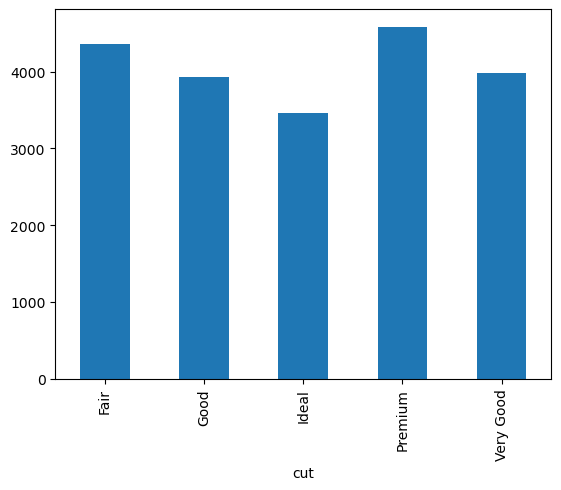

In [67]:
# Ex pandas chaining operation 
df.groupby('cut')['price'].mean().plot(kind='bar')

<Axes: >

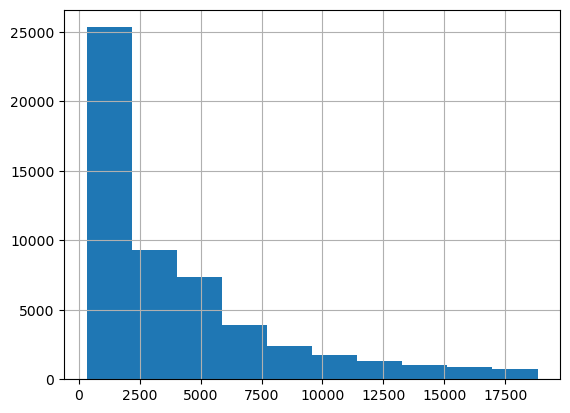

In [68]:
df["price"].astype(float).hist()

In [69]:
df["price"].astype(float).to_numpy.hist()

AttributeError: 'function' object has no attribute 'hist'